LANDIQ PROJECT - STEP 2: CREATING SCORING SYSTEM
Google Colab Version
This creates Gold/Silver/Bronze labels from the soil data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Install Libraries
!pip install geopandas -q

print("✓ Libraries installed!")

✓ Libraries installed!


In [ ]:
#Import Libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import os

print("✓ Libraries imported!")

✓ Libraries imported!


In [ ]:
#Set Working Directory
BASE_PATH = "/content/drive/MyDrive/LandIQ_Project"
os.chdir(BASE_PATH)

print(f"Working directory: {os.getcwd()}")

Working directory: /content/drive/MyDrive/LandIQ_Project


In [ ]:
#Load Data
print("Loading soil data...")
soils = gpd.read_file('soil types.shp')
print(f"✓ Loaded {len(soils)} soil mapping units")

Loading soil data...
✓ Loaded 658 soil mapping units


In [ ]:
#Define Scoring Class
class SoilHealthScorer:
    """
    Converts existing soil data into Gold/Silver/Bronze scores
    This is your MVP's CORE VALUE!
    """

    def __init__(self):
        self.scoring_weights = {
            'suitability': 40,  # Most important
            'ph': 20,
            'drainage': 20,
            'slope': 10,
            'depth': 10
        }

    def parse_ph_range(self, ph_string):
        """Convert pH string like '5.1 - 6.5' to average value"""
        if pd.isna(ph_string) or not ph_string:
            return None

        try:
            numbers = re.findall(r'\d+\.?\d*', str(ph_string))
            if len(numbers) >= 2:
                return (float(numbers[0]) + float(numbers[1])) / 2
            elif len(numbers) == 1:
                return float(numbers[0])
        except:
            return None

        return None

    def parse_slope_range(self, slope_string):
        """Extract maximum slope from string like '0 - 13%'"""
        if pd.isna(slope_string) or not slope_string:
            return None

        try:
            numbers = re.findall(r'\d+', str(slope_string))
            if numbers:
                return max([int(n) for n in numbers])
        except:
            return None

        return None

    def score_suitability(self, suitability):
        """Score based on suitability category (Max: 40 points)"""
        if pd.isna(suitability):
            return 0

        suitability = str(suitability).lower()

        if 'fairly higly suitable' in suitability or 'highly suitable' in suitability:
            return 40
        elif 'moderately suitable' in suitability:
            return 25
        elif 'marginally suitable' in suitability:
            return 10
        else:  # Currently Not Suitable
            return 0

    def score_ph(self, ph_value):
        """Score based on pH (Max: 20 points)"""
        if ph_value is None:
            return 10  # Neutral if unknown

        if 5.5 <= ph_value <= 7.0:
            return 20  # Optimal for most crops
        elif 5.0 <= ph_value <= 8.0:
            return 15  # Acceptable
        elif 4.5 <= ph_value <= 8.5:
            return 10  # Marginal
        else:
            return 5  # Challenging

    def score_drainage(self, drainage):
        """Score based on drainage (Max: 20 points)"""
        if pd.isna(drainage):
            return 10

        drainage = str(drainage).lower()

        if 'well drained' in drainage:
            return 20
        elif 'moderately drained' in drainage:
            return 15
        elif 'imperfectly drained' in drainage:
            return 12
        elif 'poorly drained' in drainage:
            return 8
        elif 'shallow drained' in drainage:
            return 6
        else:
            return 10

    def score_slope(self, slope_max):
        """Score based on slope (Max: 10 points)"""
        if slope_max is None:
            return 5

        if slope_max <= 2:
            return 10  # Flat - excellent
        elif slope_max <= 6:
            return 9   # Gentle
        elif slope_max <= 13:
            return 7   # Moderate
        elif slope_max <= 25:
            return 4   # Steep
        else:
            return 2   # Very steep

    def score_depth(self, depth):
        """Score based on soil depth (Max: 10 points)"""
        if pd.isna(depth):
            return 5

        depth = str(depth).lower()

        if 'deep' in depth:
            return 10
        elif 'shallow' in depth:
            return 3
        else:
            return 6

    def calculate_total_score(self, record):
        """Calculate total score from all factors"""
        # Parse values
        ph_value = self.parse_ph_range(record.get('SOIL_PH', ''))
        slope_max = self.parse_slope_range(record.get('SLOPE', ''))

        # Calculate component scores
        suitability_score = self.score_suitability(record.get('SUITABILIT', ''))
        ph_score = self.score_ph(ph_value)
        drainage_score = self.score_drainage(record.get('DRAINAGE', ''))
        slope_score = self.score_slope(slope_max)
        depth_score = self.score_depth(record.get('Depth', ''))

        total = suitability_score + ph_score + drainage_score + slope_score + depth_score

        breakdown = {
            'suitability_score': suitability_score,
            'ph_score': ph_score,
            'drainage_score': drainage_score,
            'slope_score': slope_score,
            'depth_score': depth_score,
            'total_score': total,
            'ph_value': ph_value,
            'slope_max': slope_max
        }

        return total, breakdown

    def assign_badge(self, total_score):
        """Convert numeric score to Gold/Silver/Bronze"""
        if total_score >= 70:
            return 'GOLD'
        elif total_score >= 45:
            return 'SILVER'
        else:
            return 'BRONZE'

    def get_degradation_risk(self, total_score, breakdown):
        """Estimate degradation risk"""
        risk_factors = []

        if breakdown['slope_score'] < 7:
            risk_factors.append('High erosion risk due to steep slope')

        if breakdown['drainage_score'] < 12:
            risk_factors.append('Waterlogging risk - poor drainage')

        if breakdown['ph_score'] < 15:
            risk_factors.append('pH stress - may need amendment')

        if breakdown['depth_score'] < 6:
            risk_factors.append('Shallow soil - limited root depth')

        if not risk_factors:
            return 'LOW', ['Well-suited for sustainable agriculture']
        elif len(risk_factors) <= 1:
            return 'MEDIUM', risk_factors
        else:
            return 'HIGH', risk_factors

print("✓ Scoring class defined!")

✓ Scoring class defined!


In [ ]:
#Initialize Scorer and Process Data
print("=" * 70)
print("SCORING ALL SOIL MAPPING UNITS")
print("=" * 70)

# Initialize scorer
scorer = SoilHealthScorer()

# Score all records
print("\nProcessing 658 records...")
results = []

for idx, row in soils.iterrows():
    total_score, breakdown = scorer.calculate_total_score(row)
    badge = scorer.assign_badge(total_score)
    degradation_risk, risk_factors = scorer.get_degradation_risk(total_score, breakdown)

    result = {
        'mapping_unit': row['MAPPING_UN'],
        'badge': badge,
        'total_score': total_score,
        'degradation_risk': degradation_risk,
        'suitability': row['SUITABILIT'],
        'drainage': row['DRAINAGE'],
        'ph_range': row['SOIL_PH'],
        'slope': row['SLOPE'],
        'soil_texture': row['SOIL_TEXTU'],
        'major_crops': row['MAJOR_CROP'],
        'risk_factors': '; '.join(risk_factors)
    }
    results.append(result)

    # Progress indicator
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/658 records...")

results_df = pd.DataFrame(results)

# Add to original geodataframe
soils['soil_health_badge'] = results_df['badge']
soils['soil_health_score'] = results_df['total_score']
soils['degradation_risk'] = results_df['degradation_risk']

print("\n✓ All records scored!")

SCORING ALL SOIL MAPPING UNITS

Processing 658 records...
  Processed 100/658 records...
  Processed 200/658 records...
  Processed 300/658 records...
  Processed 400/658 records...
  Processed 500/658 records...
  Processed 600/658 records...

✓ All records scored!


In [ ]:
#Score Distribution Statistics
print("\n" + "=" * 70)
print("SCORE DISTRIBUTION")
print("=" * 70)

badge_counts = results_df['badge'].value_counts()

print("\nBADGE DISTRIBUTION:")
for badge in ['GOLD', 'SILVER', 'BRONZE']:
    count = badge_counts.get(badge, 0)
    pct = (count / len(results_df)) * 100
    bar = "█" * int(pct / 2)
    print(f"  {badge:7s}: {count:3d} units ({pct:5.1f}%) {bar}")

print("\nDEGRADATION RISK DISTRIBUTION:")
risk_counts = results_df['degradation_risk'].value_counts()
for risk in ['LOW', 'MEDIUM', 'HIGH']:
    count = risk_counts.get(risk, 0)
    pct = (count / len(results_df)) * 100
    bar = "█" * int(pct / 2)
    print(f"  {risk:7s}: {count:3d} units ({pct:5.1f}%) {bar}")


SCORE DISTRIBUTION

BADGE DISTRIBUTION:
  GOLD   : 305 units ( 46.4%) ███████████████████████
  SILVER : 323 units ( 49.1%) ████████████████████████
  BRONZE :  30 units (  4.6%) ██

DEGRADATION RISK DISTRIBUTION:
  LOW    : 253 units ( 38.4%) ███████████████████
  MEDIUM : 242 units ( 36.8%) ██████████████████
  HIGH   : 163 units ( 24.8%) ████████████


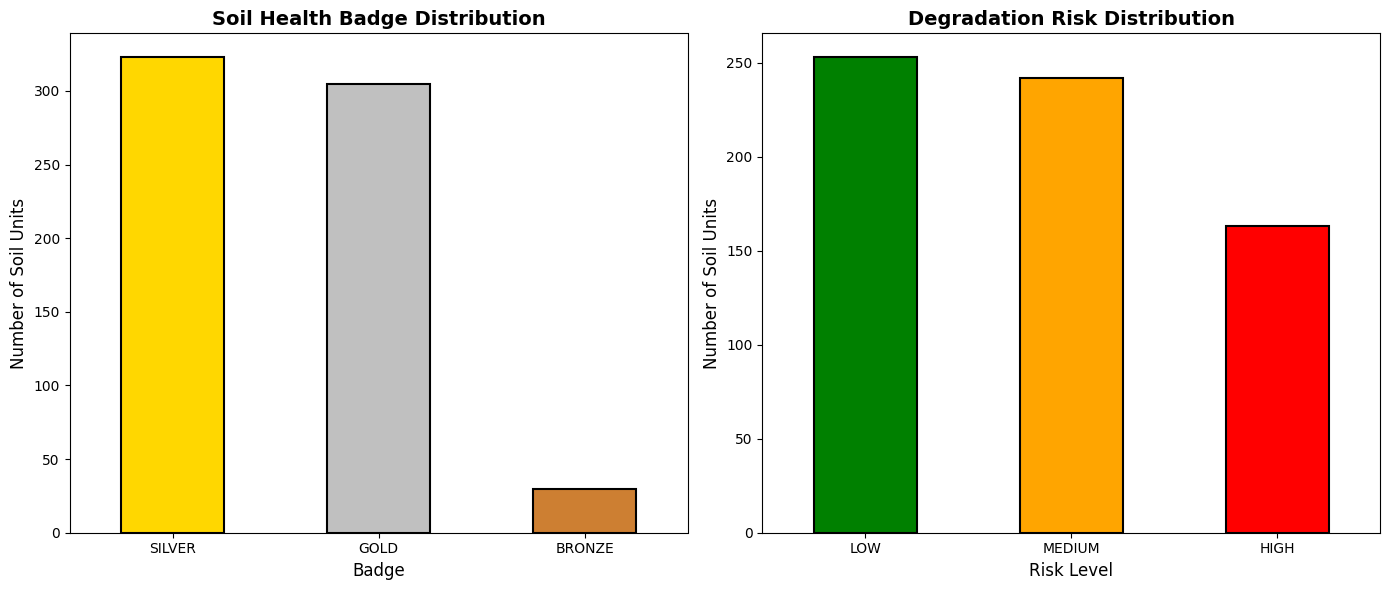

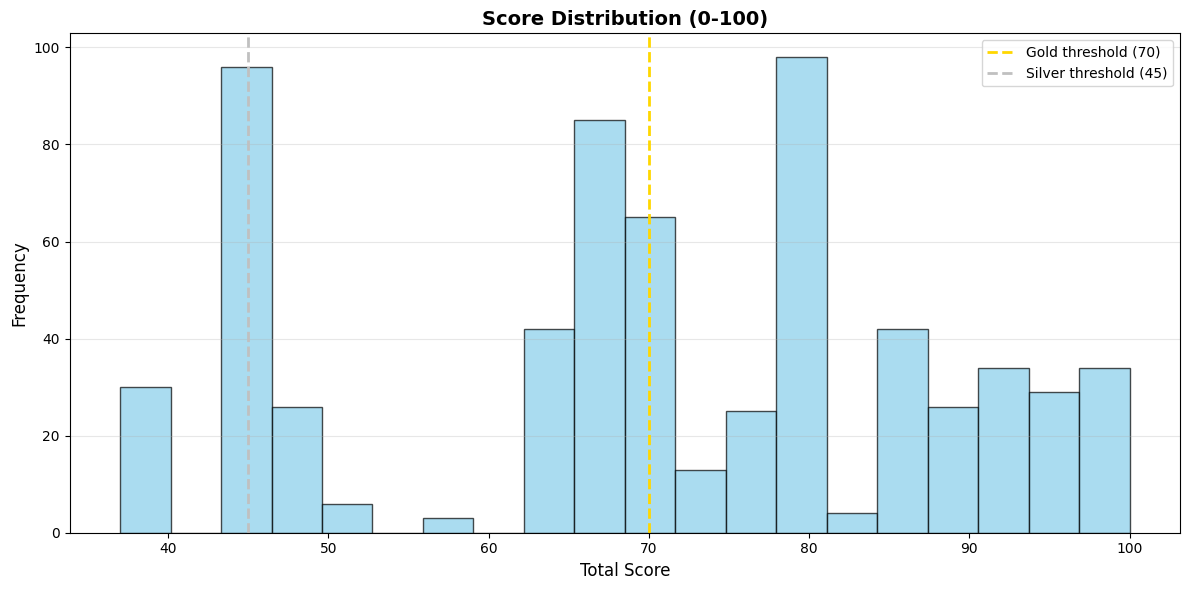

In [ ]:
# Visualizations
# Badge distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Badge distribution
badge_counts.plot(kind='bar', ax=ax1, color=['gold', 'silver', '#CD7F32'],
                  edgecolor='black', linewidth=1.5)
ax1.set_title('Soil Health Badge Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Badge', fontsize=12)
ax1.set_ylabel('Number of Soil Units', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Plot 2: Risk distribution
risk_counts.plot(kind='bar', ax=ax2, color=['green', 'orange', 'red'],
                 edgecolor='black', linewidth=1.5)
ax2.set_title('Degradation Risk Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Risk Level', fontsize=12)
ax2.set_ylabel('Number of Soil Units', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Score histogram
plt.figure(figsize=(12, 6))
plt.hist(results_df['total_score'], bins=20, color='skyblue',
         edgecolor='black', alpha=0.7)
plt.axvline(x=70, color='gold', linestyle='--', linewidth=2, label='Gold threshold (70)')
plt.axvline(x=45, color='silver', linestyle='--', linewidth=2, label='Silver threshold (45)')
plt.title('Score Distribution (0-100)', fontsize=14, fontweight='bold')
plt.xlabel('Total Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#Sample Assessments
print("\n" + "=" * 70)
print("SAMPLE ASSESSMENTS")
print("=" * 70)

for badge in ['GOLD', 'SILVER', 'BRONZE']:
    sample = results_df[results_df['badge'] == badge].iloc[0]
    print(f"\n{badge} EXAMPLE - Mapping Unit: {sample['mapping_unit']}")
    print("-" * 70)
    print(f"  Score: {sample['total_score']}/100")
    print(f"  Suitability: {sample['suitability']}")
    print(f"  pH Range: {sample['ph_range']}")
    print(f"  Drainage: {sample['drainage']}")
    print(f"  Slope: {sample['slope']}")
    print(f"  Degradation Risk: {sample['degradation_risk']}")
    print(f"  Risk Factors: {sample['risk_factors']}")
    print(f"  Suitable Crops: {sample['major_crops']}")


SAMPLE ASSESSMENTS

GOLD EXAMPLE - Mapping Unit: 15e
----------------------------------------------------------------------
  Score: 100/100
  Suitability: Fairly Higly Suitable with few physical limitation
  pH Range: 6.2 - 6.2
  Drainage: Well Drained
  Slope: 0 - 2%
  Degradation Risk: LOW
  Risk Factors: Well-suited for sustainable agriculture
  Suitable Crops: Sorghum,Maize,Yam,Cassava,Millet,Upland rice

SILVER EXAMPLE - Mapping Unit: 22a
----------------------------------------------------------------------
  Score: 46/100
  Suitability: Marginally Suitable
  pH Range: 6.2 - 6.2
  Drainage: Shallow Drained
  Slope: 0 - 13%
  Degradation Risk: HIGH
  Risk Factors: Waterlogging risk - poor drainage; Shallow soil - limited root depth
  Suitable Crops: Sorghum,Maize,Yam,Cassava,Millet,Upland rice.

BRONZE EXAMPLE - Mapping Unit: 24a
----------------------------------------------------------------------
  Score: 39/100
  Suitability: Currently Not Suitable
  pH Range: 5.1 - 5.6
  Dr

In [ ]:
#Save Results
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save labeled shapefile
soils.to_file('soil_types_labeled.shp')
print("✓ Saved: soil_types_labeled.shp (GIS file with scores)")

# Save CSV for easy viewing
results_df.to_csv('soil_health_scores.csv', index=False)
print("✓ Saved: soil_health_scores.csv (spreadsheet)")

# Save summary statistics
summary_stats = {
    'total_units': len(results_df),
    'badge_distribution': {
        'GOLD': int(badge_counts.get('GOLD', 0)),
        'SILVER': int(badge_counts.get('SILVER', 0)),
        'BRONZE': int(badge_counts.get('BRONZE', 0))
    },
    'risk_distribution': {
        'LOW': int(risk_counts.get('LOW', 0)),
        'MEDIUM': int(risk_counts.get('MEDIUM', 0)),
        'HIGH': int(risk_counts.get('HIGH', 0))
    },
    'score_statistics': {
        'mean': float(results_df['total_score'].mean()),
        'median': float(results_df['total_score'].median()),
        'min': int(results_df['total_score'].min()),
        'max': int(results_df['total_score'].max())
    }
}

with open('scoring_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("✓ Saved: scoring_summary.json (statistics)")


SAVING RESULTS


/tmp/ipython-input-310558136.py:7: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  soils.to_file('soil_types_labeled.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'soil_health_badge' to 'soil_healt'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'soil_health_score' to 'soil_hea_1'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'degradation_risk' to 'degradatio'
  ogr_write(


✓ Saved: soil_types_labeled.shp (GIS file with scores)
✓ Saved: soil_health_scores.csv (spreadsheet)
✓ Saved: scoring_summary.json (statistics)


In [ ]:
#Success Summary
print("\n" + "=" * 70)
print("✓✓✓ SCORING SYSTEM COMPLETE! ✓✓✓")
print("=" * 70)

print("\nWhat I just created:")
print("  1. Gold/Silver/Bronze labeling system")
print("  2. Degradation risk assessment")
print("  3. Labeled dataset (soil_types_labeled.shp)")
print("  4. Easy-to-read spreadsheet (soil_health_scores.csv)")

print("\nKey Statistics:")
print(f"  • Total soil units scored: {len(results_df)}")
print(f"  • Average score: {results_df['total_score'].mean():.1f}/100")
print(f"  • GOLD units: {badge_counts.get('GOLD', 0)} ({badge_counts.get('GOLD', 0)/len(results_df)*100:.1f}%)")
print(f"  • SILVER units: {badge_counts.get('SILVER', 0)} ({badge_counts.get('SILVER', 0)/len(results_df)*100:.1f}%)")
print(f"  • BRONZE units: {badge_counts.get('BRONZE', 0)} ({badge_counts.get('BRONZE', 0)/len(results_df)*100:.1f}%)")

print("\n🎉 This is the MVP's CORE VALUE!")


✓✓✓ SCORING SYSTEM COMPLETE! ✓✓✓

What I just created:
  1. Gold/Silver/Bronze labeling system
  2. Degradation risk assessment
  3. Labeled dataset (soil_types_labeled.shp)
  4. Easy-to-read spreadsheet (soil_health_scores.csv)

Key Statistics:
  • Total soil units scored: 658
  • Average score: 70.5/100
  • GOLD units: 305 (46.4%)
  • SILVER units: 323 (49.1%)
  • BRONZE units: 30 (4.6%)

🎉 This is the MVP's CORE VALUE!


In [ ]:
#Download Files
print("\n" + "=" * 70)
print("DOWNLOAD FILES")
print("=" * 70)
print("\nYou can download these files from Google Drive:")
print(f"  {BASE_PATH}/soil_types_labeled.shp (and related files)")
print(f"  {BASE_PATH}/soil_health_scores.csv")
print(f"  {BASE_PATH}/scoring_summary.json")

# Optional: Download CSV directly in Colab
from google.colab import files
download_csv = input("\nDownload CSV now? (yes/no): ").lower()

if download_csv == 'yes':
    files.download('soil_health_scores.csv')
    print("✓ Downloaded!")


DOWNLOAD FILES

You can download these files from Google Drive:
  /content/drive/MyDrive/LandIQ_Project/soil_types_labeled.shp (and related files)
  /content/drive/MyDrive/LandIQ_Project/soil_health_scores.csv
  /content/drive/MyDrive/LandIQ_Project/scoring_summary.json

Download CSV now? (yes/no): no
